In [240]:
#FULL DOMAIN RUN

# code for tracing particles back to SBZ draft (python version 3.10.9) (not optimized with numpy.where)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py

####################################################
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import os; import time

start_time = time.time();

#data loading
################################################################################################################################################################################################################
#Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
job_array=False;index_adjust=0
ocean_fraction=2/8
job_array=False

# # dx = 1 km; Np = 1M; Nt = 5 min
# data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_1e6.nc') #***
# parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_1e6.nc') #***
# res='1km'
# Np_str='1e6'

# dx = 1 km; Np = 1M; Nt = 1 min
data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_1e6_1min.nc') #***
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_1e6_1min.nc') #***
res='1km'
Np_str='1e6'

# #uncomment if using 250m data
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

# # Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,400+1))
# parcel=parcel.isel(time=np.arange(0,400+1))

############################################################################################

times=data['time'].values/(1e9 * 60); times=times.astype(float);
minutes=1/times[1] #1 / minutes per timestep = timesteps per minute
kms=np.argmax(data['xh'].values-data['xh'][0].values >= 1)

#LOADING CL MAXS FROM CL TRACKING ALGORITHM
folder = '/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/Project_Algorithms/Tracking_Algorithms/'
# open_name = folder+f'whereCL_{res}_ALL_CLS.nc'
open_name = folder+f'whereCL_{res}_ALL_CLS_1min.nc'
whereCL=xr.open_dataset(open_name).load()
whereCL=whereCL.isel(time=slice(0,len(data['time'])))
whereCL=whereCL['maxconv_x']
def Get_Conv_X(t,z,y):
    Conv_X_Max=whereCL[t,z,y,:].values
    return Conv_X_Max

In [180]:
#JOB ARRAY SETUP
job_array=True
if job_array==True:

    num_jobs=60 #how many total jobs are being run? i.e. array=1-100 ==> num_jobs=100 #***
    total_elements=len(parcel['xh']) #total num of variables

    if num_jobs >= total_elements:
        raise ValueError("Number of jobs cannot be greater than or equal to total elements.")
    
    job_range = total_elements // num_jobs  # Base size for each chunk
    remaining = total_elements % num_jobs   # Number of chunks with 1 extra 
    
    # Function to compute the start and end for each job_id
    def get_job_range(job_id):
        job_id-=1
        # Add one extra element to the first 'remaining' chunks
        start_job = job_id * job_range + min(job_id, remaining)
        end_job = start_job + job_range + (1 if job_id < remaining else 0)
    
        if job_id == num_jobs - 1: 
            end_job = total_elements #- 1
        return start_job, end_job
    # def job_testing():
    #     #TESTING
    #     start=[];end=[]
    #     for job_id in range(1,num_jobs+1):
    #         start_job, end_job = get_job_range(job_id)
    #         print(start_job,end_job)
    #         start.append(start_job)
    #         end.append(end_job)
    #     print(np.all(start!=end))
    #     print(len(np.unique(start))==len(start))
    #     print(len(np.unique(end))==len(end))
    # job_testing()
    
    job_id = int(os.environ.get('SLURM_ARRAY_TASK_ID', 0)) #this is the current SBATCH job id
    if job_id==0: job_id=60
    start_job, end_job = get_job_range(job_id)
    index_adjust=start_job
    print(f'start_job = {start_job}, end_job = {end_job}')


start_job = 983334, end_job = 1000000


In [103]:
#SUBSETTING PARCEL DATA
parcel=parcel.isel(xh=slice(start_job,end_job))

In [104]:
# Reading Back Data Later
##############
import h5py
dir2=dir+'Project_Algorithms/Lagrangian_Binary_Array/'
# open_file=dir2+f'lagrangian_binary_array_{res}_{Np_str}.h5'
open_file=dir2+f'lagrangian_binary_array_{res}_{Np_str}_1min.h5'
with h5py.File(open_file, 'r') as f:
    # Load the dataset by its name

    W = f['W'][:,start_job:end_job]
    Z = f['Z'][:,start_job:end_job]
    Y = f['Y'][:,start_job:end_job]
    X = f['X'][:,start_job:end_job]

In [105]:
# # Reading Back Data Later
# ##############
# import h5py
# dir2=dir+'Project_Algorithms/Lagrangian_Binary_Array/'
# with h5py.File(dir2+f'LFC_LCL_binary_array.h5', 'r') as f:
#     # Load the dataset by its name
#     LFC = f['LFC'][:]
#     LCL = f['LCL'][:]

# Reading Back Data Later
##############
import h5py
dir2=dir+'Project_Algorithms/Lagrangian_Binary_Array/'
# open_file=dir2+f'LFC_LCL_binary_array_{res}_{Np_str}.h5'
open_file=dir2+f'LFC_LCL_binary_array_{res}_{Np_str}_1min.h5'
with h5py.File(open_file, 'r') as f:
    # Load the dataset by its name
    LFC = f['LFC'][:,start_job:end_job]
    LCL = f['LCL'][:,start_job:end_job]

In [ ]:
#################################################################

In [521]:
#Updated Lagrangian Tracking Algorithm

#Algorithm Steps:
#(1) Find the first time a parcel is above the LFC:
#(2) First check if the parcel ascends (w>=0.1) for another 20 minutes
#(3) If so, find first time, the parcel slows down (w<0.1)
#(4) If that time is when the parcel is above 750m, save it, "forget", and move on to next parcel
#(5) If that time is when the parcel is below 750m, check if it is within 2km of the CL_Max found from the CL Tracking Algorithm
#(6) If the parcel is near the CL, store in, otherwise save it, "forget", and move on to next parcel
#(7) Continue to next parcel

#(Also, if during, traceback, the parcel escapes the x or z boundary, "forget" parcel, and move on)

In [106]:
#Numerical Settings
Nt=len(data['time'])
Np=len(parcel['xh'])
dt=times[1]*60 #300 secs

#For saving ascend-after-LFC info
ascend_lst=[]
CLmaxheight=750 #750m

#BL slow-down-threshold
w_thresh=0.1

In [107]:
# if ((x + dt*u)==0) or ((z + dt*w)==0)
# u=u[t,Z[t,p],Y[t,p],X[t,p]]; W=W[t,p]
# [u[t,Z[t,p],Y[t,p],X[t,p]] for t in time_arr] >np.max(data['xf'].values) or < np.min(data['xf'].values)
# similarly for w
################################################################################################################
#BOUNDARY-ESCAPE CONDITION
xmin=np.min(data['xf'].values)*1e3
xmax=np.max(data['xf'].values)*1e3
zmin=np.min(data['zf'].values)*1e3
zmax=np.max(data['zf'].values)*1e3

def check_boundary(p,where_BL,above_LFC):
    time_arr=np.arange(where_BL,above_LFC)

    def get_u(t,z,y,x):
        # return data['u'].isel(time=t,zh=z,yh=y).interp(xf=data['xh']).isel(xh=x).item()
        # return data['uinterp'].isel(time=t,zh=z,yh=y,uh=u).item()
        return parcel['u'][t,p].item()
    def get_x(t,p):
        return parcel['x'][t,p].item()
    def get_w(t,z,y,x):
        # return data['w'].isel(time=t,yh=y,xh=x).interp(zf=data['zh']).isel(zh=z).item()
        # return data['winterp'].isel(time=t,zh=z,yh=y,uh=u).item()
        return parcel['w'][t,p].item()
    def get_z(t,p):
        return parcel['z'][t,p].item()


    x_tend = [get_x(t, p) + dt * get_u(t, z, y, x)  
          for (t, z, y, x) in zip(time_arr, Z[time_arr, p], Y[time_arr, p], X[time_arr, p])] 
    z_tend = [get_z(t, p) + dt * get_w(t, z, y, x)  
          for (t, z, y, x) in zip(time_arr, Z[time_arr, p], Y[time_arr, p], X[time_arr, p])] 

    x_bound=any(val < xmin or val > xmax for val in x_tend)*1
    z_bound=any(val < zmin or val > zmax for val in z_tend)*1

    out=(x_bound,z_bound)
    if any(np.array(out)==1):
        print(f'parcel {p} crossed boundary between t={where_BL} and t={above_LFC}')
    return out
#############################################################################################################

In [ ]:
#############################################################################################################
#The Algorithm

In [108]:
#Initialize Output Storage Vector

#int 32 can store up to the number 2,147,483,647 
#int 32 has 4 bytes per number, so needs (Np*3)*4 bytes of memory
#Np=125000 ==> (125000*3*4)/(1024**3) = 0.001 GB
#Np=50e6 ==> (50e6*3*4)/(1024**3) = 0.56 GB

out_arr=np.zeros((Np,3)) 
save_arr=np.zeros((Np,3)) #This one is for saving continued-ascent, slow-below-750m parcels that are not with 2 km of CL
save2_arr=np.zeros((Np,3)) #This one is for saving continued-ascent, slow-above-750m parcels

In [109]:
#1--------------Looping over each parcel
for count,p in enumerate(np.arange(Np)): 

    if np.mod(p,1e4)==0: print(f'current parcel: {p}/{Np}')
    
    W_p = W[:,p]
    LFC_p = LFC[:,p] 
   
    #----FIND WHERE PARCEL IS ABOVE LFC----
    indices = np.where(LFC_p == 1)[0]; above_LFC = indices[0] if indices.size > 0 else -999; #FIRST TIME ABOVE LFC
    if above_LFC ==-999:
        print(f'parcel {p} never above LFC')
        continue #if the parcel is never above the LFC, skip the parcel
    
    #----CHECK IF ASCENDS FOR >= 20 minutes AFTER LFC----
    ascend_array=W_p[above_LFC+1:]
    indices=np.where(ascend_array==0)[0]; ascend_stop=indices[0] if indices.size > 0 else 10000; #location of where parcel stops ascending (labeled 10000 to mark for future analysis)
    ascend_lst.append(ascend_stop) #(also store for histogram)
    if ascend_stop>=20*minutes:
    
        #----FIND THE FIRST TIME W_p<=w_thresh----
        indices=np.where(W_p[0:above_LFC]<w_thresh)[0]
        where_BL=indices[-1] if indices.size > 0 else -999 #FIRST PRIOR TIME W<0.1 (IN THE BL) (ADDED 1 TO GET TIME RIGHT AFTER INTERACTION)
        if where_BL ==-999:
            print(f'parcel {p} w is never below threshold prior to t={above_LFC}')
            continue #if the parcel never slows down backwards in time (unlikely), skip the parcel
            
        #check for boundary escapes
        ################################
        future_location=check_boundary(p,where_BL,above_LFC)
        if (future_location[0]+future_location[1]>=1): continue #if parcel crosses boundary, skips current parcel
        ################################
        
        #----CHECK IF PARCEL SLOWED DOWN LOW ENOUGH----
        if parcel['z'][where_BL,p].values<=CLmaxheight: #PARCEL MUST BE BELOW 750m WHEN CONTACTING CL
        # if LCL[where_BL,p]==0: #PARCEL MUST BE BELOW LCL WHEN CONTACTING CL (not recommended)
    
            #----CHECK IF CL IS WITHIN 2km----
            #Find the CL-max x-location
            t=where_BL; z=Z[where_BL,p]; y=Y[where_BL,p]; x=X[where_BL,p]
            CONV_X=Get_Conv_X(t,z,y)
            within_CL=np.any(np.isin(CONV_X, np.arange(x-2*kms,x+3*kms)))
            
            if within_CL==True:
                #save X's (t,p) 
                print(f'Parcel {p} is success at time {where_BL}')
                out_arr[p,0]=p
                out_arr[p,1]=where_BL
                out_arr[p,2]=above_LFC 
            else: #continued-ascent, slow-below-750m parcels that are not with 2 km of CL
                #SAVE PARCEL
                print(f'Parcel {p} not near CL at t={where_BL}')
                save_arr[p,0]=p
                save_arr[p,1]=where_BL
                save_arr[p,2]=above_LFC 
    
        else: #continued-ascent, slow-above-750m parcels
            #SAVE PARCEL
            print(f'Parcel {p} above {CLmaxheight}m at t={where_BL}')
            save2_arr[p,0]=p
            save2_arr[p,1]=where_BL
            save2_arr[p,2]=above_LFC         
            
        #END OF LOOP, THEN WE MOVE ON TO NEXT PARCEL p

current parcel: 0/16667
parcel 0 w is never below threshold prior to t=0
parcel 1 w is never below threshold prior to t=0
parcel 2 w is never below threshold prior to t=0
parcel 3 w is never below threshold prior to t=0
parcel 4 w is never below threshold prior to t=0
parcel 5 w is never below threshold prior to t=0
parcel 6 w is never below threshold prior to t=0
parcel 7 w is never below threshold prior to t=0
parcel 8 w is never below threshold prior to t=0
parcel 9 w is never below threshold prior to t=0
parcel 10 w is never below threshold prior to t=0
parcel 11 w is never below threshold prior to t=0
parcel 12 w is never below threshold prior to t=0
parcel 13 w is never below threshold prior to t=0
parcel 14 w is never below threshold prior to t=0
parcel 15 w is never below threshold prior to t=0
Parcel 16 above 750m at t=329
parcel 17 w is never below threshold prior to t=0
parcel 18 w is never below threshold prior to t=0
parcel 19 w is never below threshold prior to t=0
parcel

In [110]:
#Print Ascend Storage Array
lst=np.array(ascend_lst)
lst=lst[lst!=10000]
if lst.shape[0] !=0:
    print(lst)

In [117]:
out_arr[:,0].max()

33295.0

In [113]:
#Storing output and save data
###################################################################################################################################
out_arr[np.where(np.any(out_arr != 0, axis=1))[0],0]+=index_adjust #*needed for job array*+=index_adjust #*needed for job array*
save_arr[np.where(np.any(save_arr != 0, axis=1))[0],0]+=index_adjust #*needed for job array*+=index_adjust #*needed for job array*
save2_arr[np.where(np.any(save2_arr != 0, axis=1))[0],0]+=index_adjust #*needed for job array*+=index_adjust #*needed for job array*
ds=xr.Dataset({
    'out_arr': (['rows', 'columns'], out_arr.astype(float)),
    'save_arr': (['rows', 'columns'], save_arr.astype(float)),
    'save2_arr': (['rows', 'columns'], save_arr.astype(float)),
})

# out_file = dir+f'Project_Algorithms/Tracking_Algorithms/trackout/parcel_tracking_{res}_{Np_str}_'+str(job_id)+'.nc'

out_file = dir+f'Project_Algorithms/Tracking_Algorithms/trackout/parcel_tracking_{res}_{Np_str}_'+str(job_id)+'_1min.nc'

ds.to_netcdf(out_file) #*needed for job array*
# ds.to_netcdf(dir+'tracking_algorithms/trackout/SBZlimited_parcel_tracking'+str(job_id)+'.nc')
###########################################################################################################################
end_time = time.time(); elapsed_time = end_time - start_time; print(f"Total Elapsed Time: {elapsed_time} seconds")  

Total Elapsed Time: 143.857360124588 seconds


In [62]:
############################################################
#Run after finishing job_array

In [235]:
#combine all job output arrays 
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import os; import time
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'

num_jobs=60 #***
for id in range(1, num_jobs+1):
    if np.mod(id,20)==0: print(f'job_id = {id}')
    # Open the dataset and append it to the list
    if id == 1: 
        # in_file=dir+f'Project_Algorithms/Tracking_Algorithms/trackout/parcel_tracking_{res}_{Np_str}_'+str(id)+'.nc'
        in_file=dir+f'Project_Algorithms/Tracking_Algorithms/trackout/parcel_tracking_{res}_{Np_str}_'+str(id)+'_1min.nc'
        out_arr = xr.open_dataset(in_file)['out_arr']
        save_arr = xr.open_dataset(in_file)['save_arr']
    elif id >= 2: 
        #in_file dir+f'Project_Algorithms/Tracking_Algorithms/trackout/parcel_tracking_{res}_{Np_str}_'+str(id)+'.nc'
        in_file = dir+f'Project_Algorithms/Tracking_Algorithms/trackout/parcel_tracking_{res}_{Np_str}_'+str(id)+'_1min.nc'
        
        out2 = xr.open_dataset(in_file)['out_arr']
        save2 = xr.open_dataset(in_file)['save_arr']
        out_arr=np.concatenate((out_arr, out2), axis=0)
        save_arr=np.concatenate((save_arr, save2), axis=0)
        # if np.any(out2): print(id)
ds=xr.Dataset({
    'out_arr': (['rows', 'columns'], out_arr.astype(float)),
    'save_arr': (['rows', 'columns'], save_arr.astype(float)),
})
# out_file=dir+f'Project_Algorithms/Tracking_Algorithms/trackout/parcel_tracking_{res}_{Np_str}.nc'
out_file=dir+f'Project_Algorithms/Tracking_Algorithms/trackout/parcel_tracking_{res}_{Np_str}_1min.nc'
ds.to_netcdf(out_file)

job_id = 20
job_id = 40
job_id = 60


In [ ]:
####################################################################################################
#READING OUTPUT

In [212]:
# Reading Back Data Later
##############
import h5py
dir2=dir+'Project_Algorithms/Lagrangian_Binary_Array/'
# open_file=dir2+f'lagrangian_binary_array_{res}_{Np_str}.h5'
open_file=dir2+f'lagrangian_binary_array_{res}_{Np_str}_1min.h5'
with h5py.File(open_file, 'r') as f:
    # Load the dataset by its name

    W = f['W'][:]
    Z = f['Z'][:]
    Y = f['Y'][:]
    X = f['X'][:]

In [213]:
#DOMAIN SUBSETTING
def DOMAIN_SUBSET(out_arr):
    print(f'length before: {len(out_arr)}')

    ocean_percent=2/8
    left_to_coast=data['xh'][0]+(data['xh'][-1]-data['xh'][0])*ocean_percent
    
    where_coast_xh=np.where(data['xh']>=left_to_coast)[0][0]#-25
    where_coast_xf=np.where(data['xf']>=left_to_coast)[0][0]#-25
    end_xh=len(data['xh'])-1-50
    end_xf=len(data['xf'])-1-50
    
    print(f'x in {0}:{where_coast_xh-1} FOR SEA')
    print(f'x in {where_coast_xh}:{end_xh} FOR LAND')
    # t_end=78 
    # if res=='250m':t_end=410
    # print(f't in {0}:{t_end} (6.5 hours)')
    t_start=36 
    t_end=len(data['time'])
    print(f't in {t_start}:end (8 hours)')

    #SUBSETTING CODE
    xs=X[list(out_arr[:,1]),list(out_arr[:,0])]
    
    out_arr=out_arr[np.where((xs>=where_coast_xh)&(xs<=end_xh))]
    out_arr=out_arr[np.where(out_arr[:,1]<=t_end)]

    print(f'length after: {len(out_arr)}')
    return out_arr

In [236]:
# open_file = dir+f'Project_Algorithms/Tracking_Algorithms/trackout/parcel_tracking_{res}_{Np_str}.nc'
open_file = dir+f'Project_Algorithms/Tracking_Algorithms/trackout/parcel_tracking_{res}_{Np_str}_1min.nc'

out=xr.open_dataset(open_file)['out_arr'].values;out=out.astype(object);out[:, [0,1,2]] = out[:, [0,1,2]].astype(int) #***
save=xr.open_dataset(open_file)['save_arr'].values;save=save.astype(object);save[:, [0,1,2]] = save[:, [0,1,2]].astype(int) #***

out_arr=out[~np.all(out == 0, axis=1)];#print('list of first 10 SBZ parcels'); print(out_arr[:15])
save_arr=save[~np.all(save == 0, axis=1)];save_arr=save_arr[np.where(np.unique(save_arr[1:-1,0]))];#print('list of first 10 ignored parcels');print(save_arr[:5])

###############################################################################
#remove duplicates
lst=[]
unique_values, counts = np.unique(out_arr[:,0], return_counts=True); duplicates = unique_values[counts > 1]
for elem in duplicates:
    idx = np.where(out_arr[:,0] == elem)[0] 
    extras=idx[np.where(out_arr[idx,2]!=np.min(out_arr[idx,2]))]
    lst.extend([x for x in extras])
mask=np.ones(len(out_arr), dtype=bool); mask[lst] = False
out_arr=out_arr[mask]; 
###############################################################################

out_arr=out[~np.all(out == 0, axis=1)];print('list of first 10 SBZ parcels'); print(out_arr[:15])
save_arr=save[~np.all(save == 0, axis=1)];save_arr=save_arr[np.where(np.unique(save_arr[1:-1,0]))];print('list of first 10 ignored parcels');print(save_arr[:5])
placeholder=out_arr.copy(); run=True
############################################################
print(f'there are a total of {len(out_arr)} CL parcels and {len(save_arr)} nonCL parcels')

############################################################
#SUBSETTING
subset=True
if subset==True:
    out_arr=DOMAIN_SUBSET(out_arr)
    save_arr=DOMAIN_SUBSET(save_arr)
############################################################

ALL_out_arr=out_arr.copy(); ALL_save_arr=save_arr.copy()

list of first 10 SBZ parcels
[[34 403 429]
 [74 326 346]
 [128 402 417]
 [246 279 295]
 [314 278 290]
 [398 273 286]
 [444 279 293]
 [635 278 292]
 [679 269 290]
 [741 384 397]
 [743 411 424]
 [812 310 327]
 [838 264 282]
 [874 547 567]
 [880 409 435]]
list of first 10 ignored parcels
[[72 325 359]
 [149 260 284]
 [160 270 292]
 [232 266 289]
 [363 367 386]]
there are a total of 15158 CL parcels and 11243 nonCL parcels
length before: 15158
x in 0:127 FOR SEA
x in 128:461 FOR LAND
t in 36:end (8 hours)
length after: 15116
length before: 11243
x in 0:127 FOR SEA
x in 128:461 FOR LAND
t in 36:end (8 hours)
length after: 8134


In [8]:
#SHALLOW
parcel_z=parcel['z'].data

def ddt(f,dt=1):
    ddx = (
            f[1:  ]
            -
            f[0:-1]
        ) / (
        2 * dt
    )
    return ddx

#search for deep convective parcels within lagrangian tracking output     
##############################################################
def SHALLOW_threshold(zthresh,type):

    if type=='CL':
        out_arr=ALL_out_arr.copy()
    elif type=='nonCL':
        out_arr=ALL_save_arr.copy()
    
    deep_out_ind=[]; extendrange=[]
    times=data['time'].values/(1e9 * 60); times=times.astype(float);
    for ind in range(len(out_arr)): 
        if np.mod(ind,5000)==0: print(f'{ind}/{len(out_arr)}')
        #CHECK TO SSEE IF NEXT MOST LOCAL TIME MAX GOES ABOVE ZTHRESHS 

        #Get Ascending Range Past LFC For Maximum 120 Minutes Simulation Time
        nummins=120; numsteps=int(nummins/times[1])
        aboverange=np.arange(out_arr[ind,2],out_arr[ind,2]+numsteps,1) #range of times between current time and numsteps later
        aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
        above=parcel_z[aboverange,out_arr[ind,0]]/1000
    
        #Takes The time derivative 
        ddx=ddt(above)

        #Checks whether the Local Time Max Is Located Above zthresh
        signs = np.sign(ddx)
        signs_diff=np.diff(signs)
        local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
        if len(local_maxes)==0:
            local_maxes=[0]
        elif np.any(above[local_maxes[0]]<=zthresh): #< for SHALLOW, > for DEEP
            extendrange.append(local_maxes[0]) #save to extend xlim of plot later
            deep_out_ind.append(ind)

    #SUBSET OUT FOR FINAL RESULT
    out_arr=out_arr[deep_out_ind,:]
    # print(f'> {zthresh} km. {len(out_arr)} leftover parcels')
    return out_arr#, extendrange
    # print(out_arr)
##############################################################

convectivelevel=4 #4km
SHALLOW_out_arr=SHALLOW_threshold(convectivelevel,type='CL')
SHALLOW_save_arr=SHALLOW_threshold(convectivelevel,type='nonCL')

print('list of first 10 SBZ parcels'); print(out_arr[:15])
print(f'there are a total of {len(SHALLOW_out_arr)} CL parcels and {len(SHALLOW_save_arr)} nonCL parcels')

0/14941
5000/14941
10000/14941
0/14725
5000/14725
10000/14725
list of first 10 SBZ parcels
[[18 76 80]
 [74 65 70]
 [126 67 73]
 [128 80 84]
 [244 72 76]
 [398 54 58]
 [444 54 60]
 [635 55 59]
 [741 76 80]
 [743 82 85]
 [812 62 66]
 [880 80 87]
 [954 72 76]
 [1007 107 111]
 [1022 68 71]]
there are a total of 10267 CL parcels and 11130 nonCL parcels


In [11]:
#DEEP
parcel_z=parcel['z'].data

#search for deep convective parcels within lagrangian tracking output     
##############################################################
def DEEP_threshold(zthresh,type):
    if type=='CL':
        out_arr=ALL_out_arr.copy()
    elif type=='nonCL':
        out_arr=ALL_save_arr.copy()
    
    deep_out_ind=[]; extendrange=[]
    times=data['time'].values/(1e9 * 60); times=times.astype(float);
    for ind in range(len(out_arr)): 
        if np.mod(ind,5000)==0: print(f'{ind}/{len(out_arr)}')
        #CHECK TO SSEE IF NEXT MOST LOCAL TIME MAX GOES ABOVE ZTHRESHS 

        #Get Ascending Range Past LFC For Maximum 120 Minutes Simulation Time
        nummins=120; numsteps=int(nummins/times[1])
        aboverange=np.arange(out_arr[ind,2],out_arr[ind,2]+numsteps,1) #range of times between current time and numsteps later
        aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
        above=parcel_z[aboverange,out_arr[ind,0]]/1000
        
        #Takes The time derivative 
        ddx=ddt(above)

        #Checks whether the Local Time Max Is Located Above zthresh
        signs = np.sign(ddx)
        signs_diff=np.diff(signs)
        local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
        if len(local_maxes)==0:
            local_maxes=[0]
        
        if np.any(above[local_maxes[0]]>=zthresh): #< for SHALLOW, > for DEEP
            extendrange.append(local_maxes[0]) #save to extend xlim of plot later
            deep_out_ind.append(ind)

    #SUBSET OUT FOR FINAL RESULT
    out_arr=out_arr[deep_out_ind,:]
    # print(f'> {zthresh} km. {len(out_arr)} leftover parcels')
    return out_arr#, extendrange
    # print(out_arr)
##############################################################

convectivelevel=6 #4km
DEEP_out_arr=DEEP_threshold(convectivelevel,type='CL')
DEEP_save_arr=DEEP_threshold(convectivelevel,type='nonCL')

print('list of first 10 SBZ parcels'); print(out_arr[:15])
print(f'there are a total of {len(DEEP_out_arr)} CL parcels and {len(DEEP_save_arr)} nonCL parcels')

0/14941
5000/14941
10000/14941
0/14725
5000/14725
10000/14725
list of first 10 SBZ parcels
[[18 76 80]
 [74 65 70]
 [126 67 73]
 [128 80 84]
 [244 72 76]
 [398 54 58]
 [444 54 60]
 [635 55 59]
 [741 76 80]
 [743 82 85]
 [812 62 66]
 [880 80 87]
 [954 72 76]
 [1007 107 111]
 [1022 68 71]]
there are a total of 1520 CL parcels and 1405 nonCL parcels


In [ ]:
# Reading Back Data Later
##############
import h5py
dir2=dir+'Project_Algorithms/Lagrangian_Binary_Array/'

in_file=dir2+f'lagrangian_binary_array_{res}_{Np_str}.h5'
in_file=dir2+f'lagrangian_binary_array_{res}_{Np_str}_1min.h5'
with h5py.File(in_file, 'r') as f:
    # Load the dataset by its name
    A_g = f['A_g'][:]
    A_c = f['A_c'][:]

    # W = f['W'][:]
    # QCQI = f['QCQI'][:]
    Z = f['Z'][:]
    Y = f['Y'][:]
    X = f['X'][:]

# #Making Time Matrix
# rows, cols = A.shape[0], A.shape[1]
# T = np.arange(rows).reshape(-1, 1) * np.ones((1, cols), dtype=int)

In [66]:
#FINDING SBZ CONVERGENCE
parcel_z=parcel['z'].data

#FIND ALL X MAXES
import sys
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir+'../Functions'
sys.path.append(path)
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

# TF=False
# if TF==False:
#     print('Loading In Data')
#     u_data=data['u'].interp(xf=data['xh']).data
#     v_data=data['v'].interp(yf=data['yh']).data
#     TF=True


from NumericalFunctions import *
def find_SBZ_xmaxs():
    
    # print('calculating convergence and taking mean')
    # Conv=-(Ddx(u_data,1000)+Ddy(v_data,1000))
    dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
    file_path = dir2 + 'Variable_Calculation/' + 'Convergence' + f'_{res}' + '.h5'
    with h5py.File(file_path, 'r') as f:
        Conv = f['conv'][:]
    
    zlev=4
    Conv_ymean=np.mean(Conv[:,zlev],axis=1)
    xmaxs=np.argmax(Conv_ymean, axis=1)

    return xmaxs
def find_SBZ_xmaxs():
    # Define the directory and file path
    dir2 = '/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
    file_path = dir2 + 'Variable_Calculation/' + 'Convergence' + f'_{res}_{Np_str}' + '.h5'
    
    # Open the HDF5 file in read mode
    with h5py.File(file_path, 'r') as f:
        # Access the 'conv' dataset
        conv_dataset = f['conv']
        
        # Define the vertical level you are interested in
        zlev = 4
        
        # Initialize a list to store the xmaxs for each time step
        xmaxs_list = []

        # Loop over each time step (axis=0 corresponds to time)
        for t in range(conv_dataset.shape[0]):  # conv_dataset.shape[0] is the time dimension size
            # Read the relevant slice for this time step and vertical level
            Conv_t_zlev = conv_dataset[t, zlev, :, :]  # Shape should be (y_size, x_size)
            
            # Calculate the mean across the y-axis
            Conv_ymean = np.mean(Conv_t_zlev, axis=0)  # Mean across the y-axis
            
            # Find the index of the maximum value along the x-axis
            xmax = np.argmax(Conv_ymean)
            
            # Append the result for this time step
            xmaxs_list.append(xmax)
    
    # Convert the list of xmaxs to a numpy array (optional)
    xmaxs = np.array(xmaxs_list)

    return xmaxs #returns SBZ x location for each timestep


def subset_SBZ(out_arr):
    xmaxs=find_SBZ_xmaxs()

    SBZ_subset=[]
    # test=[] #TESTING
    
    for ind in np.arange(out_arr.shape[0]):
        
        row=out_arr[ind]
        p=row[0]
        t=row[1]

        kms=np.argmax(data['xh'].values-data['xh'][0].values >= 1)
        if X[t,p] in np.arange( (xmaxs[t]-2*kms),(xmaxs[t]+2*kms) +1):
            SBZ_subset.append(ind)
            # test.append(p) #TESTING
    
    SBZ_out_arr=out_arr[SBZ_subset]
    print(f'there are a total of {len(SBZ_out_arr)} ALL SBZ CL parcels')

    valid_range=np.arange(out_arr.shape[0])
    nonSBZ_out_arr=out_arr[list(set(valid_range) - set(SBZ_subset))]
    print(f'there are a total of {len(nonSBZ_out_arr)} ALL nonSBZ CL parcels')
    return SBZ_out_arr,nonSBZ_out_arr


# #LOADING CL MAXS FROM CL TRACKING ALGORITHM
# folder = '/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/Project_Algorithms/Tracking_Algorithms/'
# whereSBZ=xr.open_dataset(folder+f'whereCL_{res}_ONLY_SBZS.nc').load()
# whereSBZ=whereSBZ.isel(time=slice(0,len(data['time'])))
# whereSBZ=whereSBZ['maxconv_x']
# def Get_SBZ_X(t,z,y):
#     Conv_X_Max=whereSBZ[t,z,y,:].values
#     return Conv_X_Max
# def subset_SBZ(out_arr):

#     SBZ_subset=[]
#     # test=[] #TESTING
    
#     for ind in np.arange(out_arr.shape[0]):
        
#         row=out_arr[ind]
#         p=row[0]
#         t=row[1]

#         kms=np.argmax(data['xh'].values-data['xh'][0].values >= 1)
#         value=X[t,p]
#         if np.any((value >= xmaxs - 2*kms) & (value <= xmaxs + 2*kms))==True:
#             SBZ_subset.append(ind)
#             # test.append(p) #TESTING
    
#     SBZ_out_arr=out_arr[SBZ_subset]
#     print(f'there are a total of {len(SBZ_out_arr)} ALL SBZ CL parcels')

#     valid_range=np.arange(out_arr.shape[0])
#     nonSBZ_out_arr=out_arr[list(set(valid_range) - set(SBZ_subset))]
#     print(f'there are a total of {len(nonSBZ_out_arr)} ALL nonSBZ CL parcels')
#     return SBZ_out_arr,nonSBZ_out_arr

#SUBSETTING OUT SHALLOW AND DEEP FROM SBZ AND NONSBZ
def SHALLOW_threshold(zthresh,type):
    if type=='SBZ':
        out_arr=ALL_SBZ_out_arr.copy()
    elif type=='nonSBZ':
        out_arr=ALL_nonSBZ_out_arr.copy()
    
    deep_out_ind=[]; extendrange=[]
    times=data['time'].values/(1e9 * 60); times=times.astype(float);
    for ind in range(len(out_arr)): 
        # if np.mod(ind,5000)==0: print(f'{ind}/{len(out_arr)}')
        #CHECK TO SSEE IF NEXT MOST LOCAL TIME MAX GOES ABOVE ZTHRESHS 

        #Get Ascending Range Past LFC For Maximum 120 Minutes Simulation Time
        nummins=120; numsteps=int(nummins/times[1])
        aboverange=np.arange(out_arr[ind,2],out_arr[ind,2]+numsteps,1) #range of times between current time and numsteps later
        aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
        above=parcel_z[aboverange,out_arr[ind,0]]/1000
        
        #Takes The time derivative 
        ddx=ddt(above)

        #Checks whether the Local Time Max Is Located Above zthresh
        signs = np.sign(ddx)
        signs_diff=np.diff(signs)
        local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
        if len(local_maxes)==0:
            local_maxes=[0]
        
        if np.any(above[local_maxes[0]]<=zthresh): #< for SHALLOW, > for DEEP
            extendrange.append(local_maxes[0]) #save to extend xlim of plot later
            deep_out_ind.append(ind)

    #SUBSET OUT FOR FINAL RESULT
    out_arr=out_arr[deep_out_ind,:]
    # print(f'> {zthresh} km. {len(out_arr)} leftover parcels')
    return out_arr#, extendrange
    # print(out_arr)

def DEEP_threshold(zthresh,type):
    if type=='SBZ':
        out_arr=ALL_SBZ_out_arr.copy()
    elif type=='nonSBZ':
        out_arr=ALL_nonSBZ_out_arr.copy()

    deep_out_ind=[]; extendrange=[]
    times=data['time'].values/(1e9 * 60); times=times.astype(float);
    for ind in range(len(out_arr)): 
        # if np.mod(ind,5000)==0: print(f'{ind}/{len(out_arr)}')
        #CHECK TO SSEE IF NEXT MOST LOCAL TIME MAX GOES ABOVE ZTHRESHS 
        
        #Get Ascending Range Past LFC For Maximum 120 Minutes Simulation Time
        nummins=120; numsteps=int(nummins/times[1])
        aboverange=np.arange(out_arr[ind,2],out_arr[ind,2]+numsteps,1) #range of times between current time and numsteps later
        aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
        above=parcel_z[aboverange,out_arr[ind,0]]/1000
    
        #Takes The time derivative 
        ddx=ddt(above)

        #Checks whether the Local Time Max Is Located Above zthresh
        signs = np.sign(ddx)
        signs_diff=np.diff(signs)
        local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
        if len(local_maxes)==0:
            local_maxes=[0]
        
        if np.any(above[local_maxes[0]]>=zthresh): #< for SHALLOW, > for DEEP
            extendrange.append(local_maxes[0]) #save to extend xlim of plot later
            deep_out_ind.append(ind)

    #SUBSET OUT FOR FINAL RESULT
    out_arr=out_arr[deep_out_ind,:]
    # print(f'> {zthresh} km. {len(out_arr)} leftover parcels')
    return out_arr#, extendrange
    # print(out_arr)
##############################################################
[ALL_SBZ_out_arr,ALL_nonSBZ_out_arr]=subset_SBZ(ALL_out_arr)
SHALLOW_SBZ_out_arr=SHALLOW_threshold(4,'SBZ')
print(f'there are a total of {len(SHALLOW_SBZ_out_arr)} SHALLOW SBZ CL parcels')
SHALLOW_nonSBZ_out_arr=SHALLOW_threshold(4,'nonSBZ')
print(f'there are a total of {len(SHALLOW_nonSBZ_out_arr)} SHALLOW nonSBZ CL parcels')
DEEP_SBZ_out_arr=DEEP_threshold(6,'SBZ')
print(f'there are a total of {len(DEEP_SBZ_out_arr)} DEEP SBZ CL parcels')
DEEP_nonSBZ_out_arr=DEEP_threshold(6,'nonSBZ')
print(f'there are a total of {len(DEEP_nonSBZ_out_arr)} DEEP nonSBZ CL parcels')

there are a total of 827 ALL SBZ CL parcels
there are a total of 14114 ALL nonSBZ CL parcels
there are a total of 432 SHALLOW SBZ CL parcels
there are a total of 10087 SHALLOW nonSBZ CL parcels
there are a total of 189 DEEP SBZ CL parcels
there are a total of 1331 DEEP nonSBZ CL parcels


In [171]:
####################################################################################################
#PLOTTING TRAJECTORIES

In [37]:
# # Reading Back Data Later
# ##############
# import h5py
# dir2=dir+'Project_Algorithms/Lagrangian_Binary_Array/'
# # open_file=dir2+f'lagrangian_binary_array_{res}_{Np_str}.h5'
# open_file=dir2+f'lagrangian_binary_array_{res}_{Np_str}_1min.h5'
# with h5py.File(open_file, 'r') as f:
#     # Load the dataset by its name
#     # A_g = f['A_g'][:]
#     # A_c = f['A_c'][:]

#     W = f['W'][:]
#     # QCQI = f['QCQI'][:]
#     Z = f['Z'][:]
#     Y = f['Y'][:]
#     X = f['X'][:]

# #Making Time Matrix
# rows, cols = Z.shape[0], Z.shape[1]
# T = np.arange(rows).reshape(-1, 1) * np.ones((1, cols), dtype=int)


In [56]:
# out_arr=ALL_out_arr
out_arr=SHALLOW_out_arr
# out_arr=DEEP_out_arr


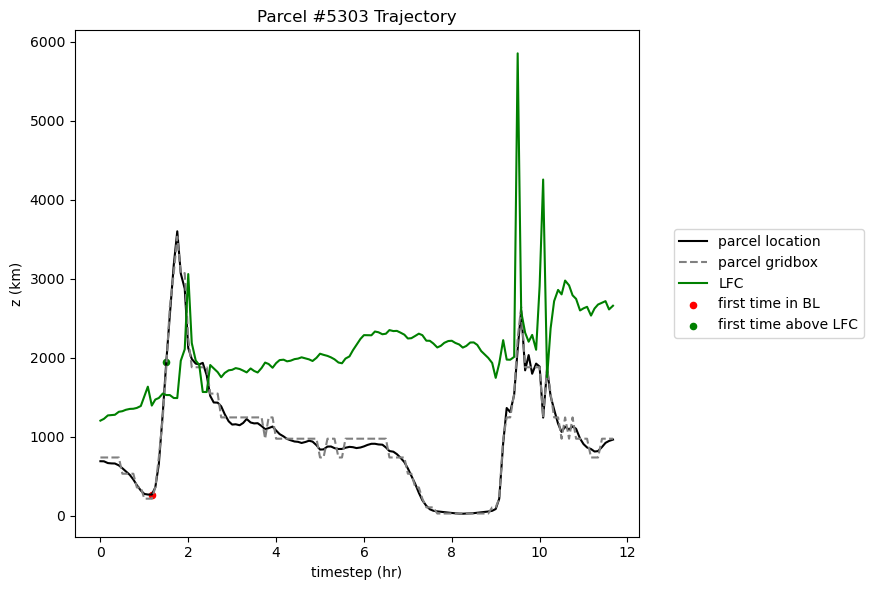

In [61]:
# import matplotlib.pyplot as plt
# import matplotlib.gridspec as gridspec
# import numpy as np

# # Assuming 'data', 'ALL_out_arr', 'parcel', 'LFC_data', 'Z', 'T', 'Y', 'X', etc., are already defined

# # Define grid for the plot and legend
# fig = plt.figure(figsize=(10, 6))
# gs = gridspec.GridSpec(1, 2, width_ratios=[0.85, 0.15])  # 1 row, 2 columns, second column is smaller for legend

# # Define the first subplot for the trajectory plot
# ax1 = plt.subplot(gs[0])

# # Define time steps and other data
# tsteps = np.arange(len(data['time'])) * 5 / 60
# tsteps = np.round(tsteps, 2)

# i = 40
# p = out_arr[i, 0]
# t1 = out_arr[i, 1]
# t2 = out_arr[i, 2]

# z1 = parcel['z'][t1, p]
# z2 = parcel['z'][t2, p]

# zs = parcel['z'][:, p]
# zgrids = data['zh'][Z[:, p]] * 1000

# lfcs = LFC_data[T[:, p], Y[:, p], X[:, p]]

# # Plot parcel trajectory, grid, and LFC
# ax1.plot(tsteps, zs, color='black', label='parcel location')
# ax1.plot(tsteps, zgrids, linestyle='dashed', color='grey', label='parcel gridbox')
# ax1.plot(tsteps, lfcs, color='green', label='LFC')
# ax1.scatter(t1 * 5 / 60, z1, color='red', s=20, label='first time in BL')
# ax1.scatter(t2 * 5 / 60, z2, color='green', s=20, label='first time above LFC')

# # Labels and title
# ax1.set_xlabel('timestep (hr)')
# ax1.set_ylabel('z (km)')
# ax1.set_title(f'Parcel #{p} Trajectory')

# # Set up legend in the second subplot (outside of the plot)
# # Adjusting bbox_to_anchor to move legend outside
# ax1.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', fontsize=10)

# # Adjust layout to prevent overlap
# fig.tight_layout()

# # Show the plot
# plt.show()
